# 🎓 TP Étudiant : Visualisation Avancée & Machine Learning
**Cours : Data Management - Course 7**

--- 

## 🎯 Objectifs
Ce TP met en pratique les concepts avancés de visualisation et de modélisation vus en cours :
1.  **Visualisation Multidimensionnelle** : Pair Plots, Parallel Coordinates.
2.  **Visualisation Interactive** : Utilisation de Plotly.
3.  **Séries Temporelles** : Décomposition saisonnière.
4.  **Réseaux (Graphes)** : Visualisation de nœuds et liens.
5.  **Machine Learning & Feature Engineering** : Random Forest, Importance des variables, Scaling.

📝 **Consigne** : Les parties de code manquantes sont indiquées par `# --- À COMPLÉTER ---`. À vous de jouer !

## 🛠️ Étape 0 : Préparation de l'environnement
Importation des librairies nécessaires. Nous utiliserons `Seaborn` et `Plotly` pour la visualisation, `NetworkX` pour les graphes, et `Scikit-Learn` pour le ML.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import networkx as nx
from statsmodels.tsa.seasonal import seasonal_decompose

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

# Configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("Librairies chargées !")

Librairies chargées !


--- 
## 1️⃣ Visualisation Multidimensionnelle

Nous allons utiliser le célèbre dataset **Iris** pour visualiser les relations entre plusieurs variables simultanément.

In [2]:
# Chargement du dataset Iris
df_iris = sns.load_dataset('iris')
display(df_iris.head())

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### 1.1 Pair Plot (Matrice de Scatterplots)
Le Pair Plot permet de voir les relations bivariées entre toutes les paires de variables (Slide 28).

**Exercice :** Utilisez `sns.pairplot` pour visualiser les relations, en colorant les points selon l'espèce (`hue`).

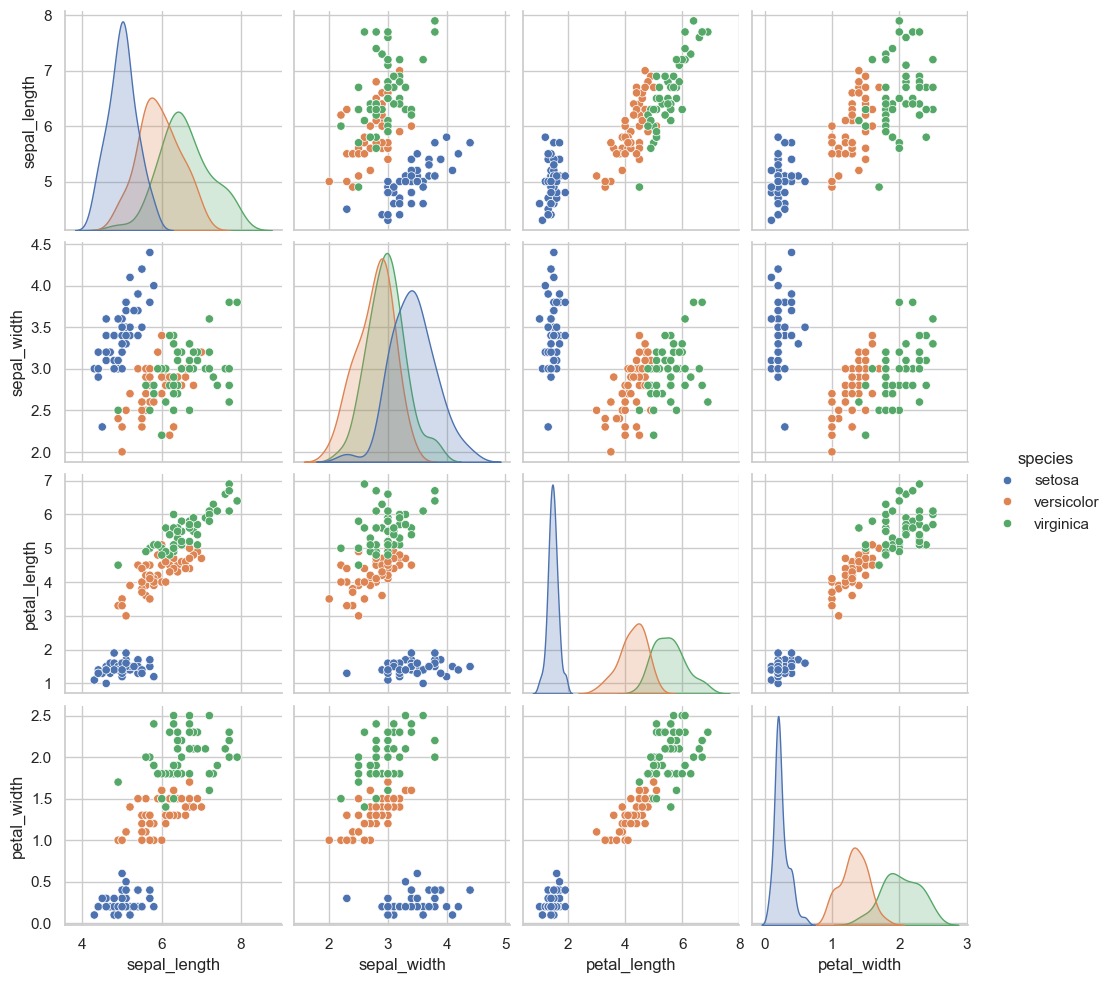

In [15]:
# Création du Pair Plot avec hue='species'
sns.pairplot(df_iris, hue='species')
plt.show()

### 1.2 Parallel Coordinates
Idéal pour comparer les profils de données multidimensionnelles (Slide 5).
Nous utiliserons `pd.plotting.parallel_coordinates`.

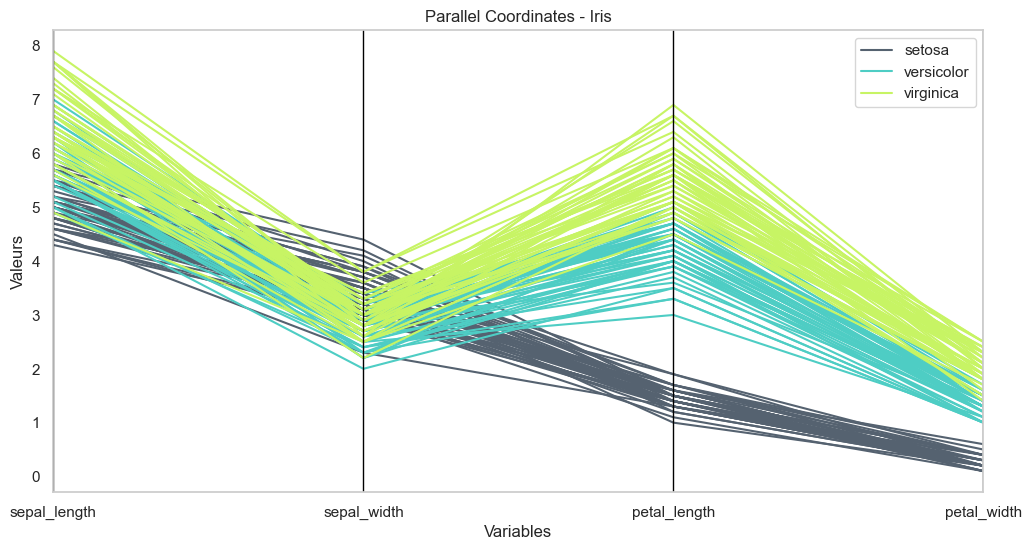

In [4]:
plt.figure(figsize=(12, 6))

# Création du graphique Parallel Coordinates
pd.plotting.parallel_coordinates(df_iris, 'species', color=('#556270', '#4ECDC4', '#C7F464'))

plt.title("Parallel Coordinates - Iris")
plt.xlabel("Variables")
plt.ylabel("Valeurs")
plt.legend(loc='best')
plt.show()

--- 
## 2️⃣ Visualisation Interactive (Plotly)

Les graphiques statiques sont limités. `Plotly` permet de zoomer et survoler les données (Slide 12).

In [5]:
# Création d'un scatter plot interactif
# Axe X : sepal_width, Axe Y : sepal_length, Couleur : species, Taille : petal_length

fig = px.scatter(
    data_frame=df_iris,
    x='sepal_width',
    y='sepal_length',
    color='species',
    size='petal_length',
    hover_data=['petal_width'],
    title="Graphique Interactif Iris (Plotly)"
)

fig.show()

--- 
## 3️⃣ Séries Temporelles (Time Series)

Nous allons analyser les données de passagers aériens (tendance + saisonnalité, Slide 21).

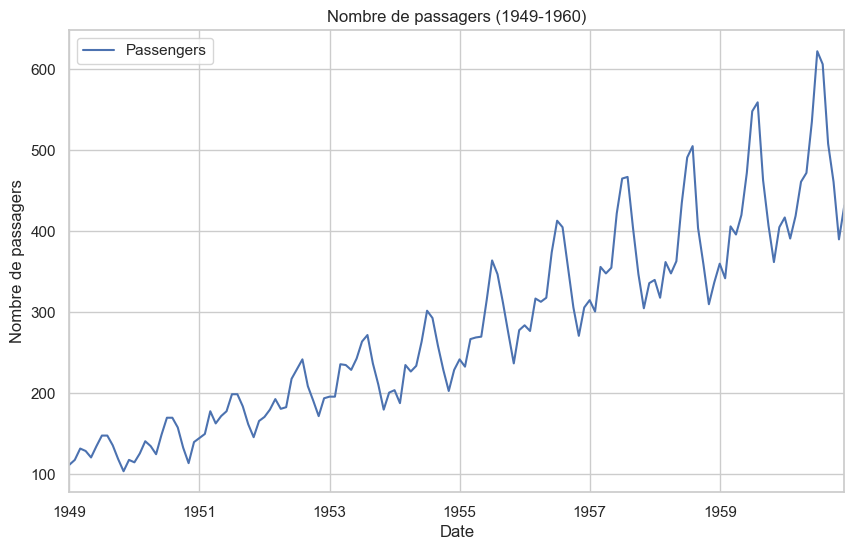

In [14]:
# Chargement des données (Air Passengers)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df_air = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

df_air.plot(title="Nombre de passagers (1949-1960)")
plt.xlabel("Date")
plt.ylabel("Nombre de passagers")
plt.show()

### 3.1 Décomposition Saisonnière
Utilisez `seasonal_decompose` pour séparer la **Tendance** (Trend), la **Saisonnalité** (Seasonal) et le **Bruit** (Residual).

**Exercice :** Appliquez la décomposition et affichez le résultat.

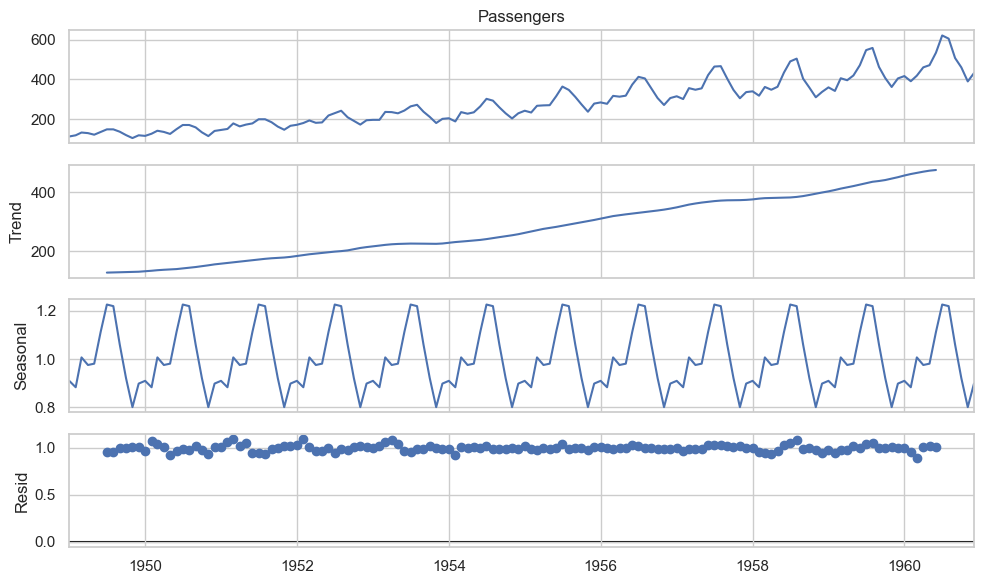

In [7]:
# Décomposition saisonnière avec modèle multiplicatif
result = seasonal_decompose(df_air['Passengers'], model='multiplicative', period=12)

# Affichage des composantes
result.plot()
plt.tight_layout()
plt.show()

--- 
## 4️⃣ Analyse de Réseaux (Network Visualization)

Visualisons un graphe simple (ex: le club de Karaté de Zachary, Slide 23/25) pour voir les connexions.

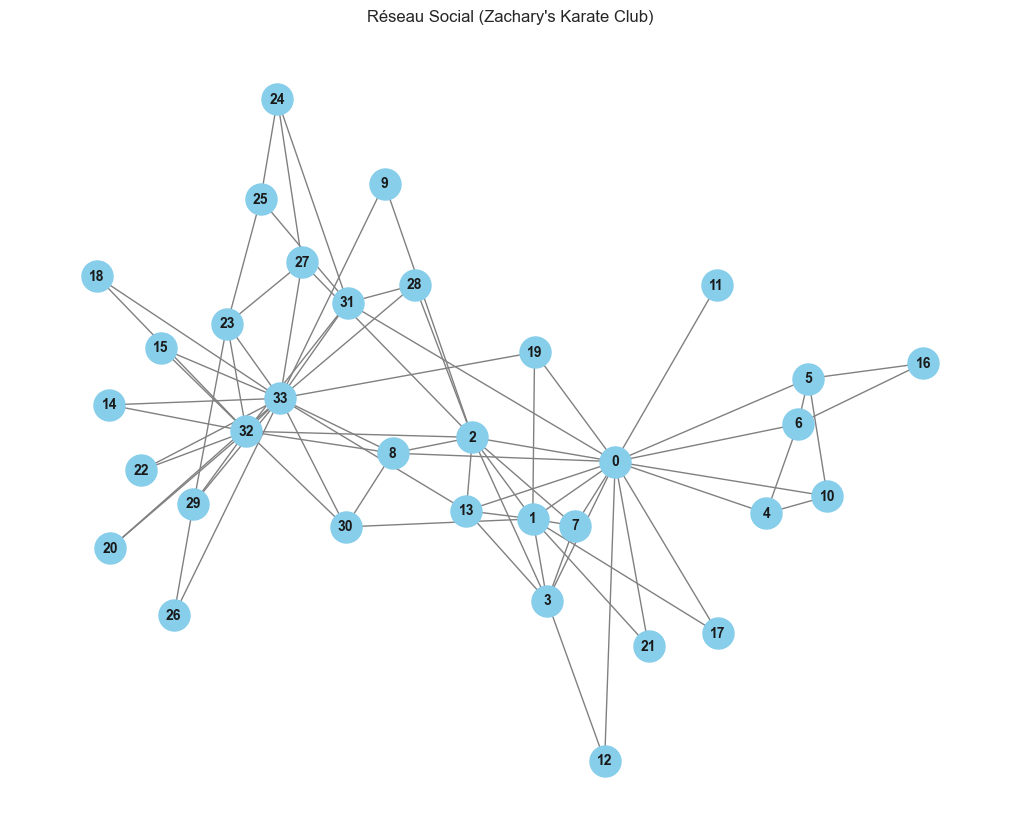

Nombre de nœuds : 34
Nombre de liens : 78


In [ ]:
# Création du graphe
G = nx.karate_club_graph()

plt.figure(figsize=(10, 8))

# Dessin du graphe avec NetworkX
nx.draw(G, with_labels=True, node_color='skyblue', node_size=500, 
        edge_color='gray', font_size=10, font_weight='bold')

plt.title("Réseau Social (Zachary's Karate Club)")
plt.axis('off')
plt.show()

# Statistiques du graphe
print(f"Nombre de nœuds : {G.number_of_nodes()}")
print(f"Nombre de liens : {G.number_of_edges()}")  #les noeuds sont les points et les edges sont les liens entre les points

--- 
## 5️⃣ Machine Learning & Feature Engineering

Nous allons prédire l'espèce des fleurs Iris en utilisant un **Random Forest** et analyser l'importance des variables (Slide 26).

### 5.1 Feature Engineering : Scaling
Les algorithmes fonctionnent souvent mieux avec des données normalisées (Slide 28).

In [9]:
X = df_iris.drop('species', axis=1)
y = df_iris['species']

# Séparation Train / Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialisation du StandardScaler
scaler = StandardScaler()

# Transformation des données (fit sur train, transform sur train et test)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Données normalisées !")
print(f"Taille de l'ensemble d'entraînement : {X_train_scaled.shape}")
print(f"Taille de l'ensemble de test : {X_test_scaled.shape}")

Données normalisées !
Taille de l'ensemble d'entraînement : (105, 4)
Taille de l'ensemble de test : (45, 4)


### 5.2 Entraînement du modèle (Random Forest)
**Exercice :** Entraînez un `RandomForestClassifier` et calculez sa précision.

In [10]:
# 1. Initialisation
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Entraînement (Fit) sur les données normalisées
model.fit(X_train_scaled, y_train)

# 3. Prédiction
y_pred = model.predict(X_test_scaled)

# 4. Évaluation
acc = accuracy_score(y_test, y_pred)
print(f"Précision du modèle : {acc:.2%}")

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
print("\nMatrice de confusion :")
print(cm)

Précision du modèle : 100.00%

Matrice de confusion :
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


### 5.3 Interprétation : Feature Importance
Quelles variables ont le plus pesé dans la décision du modèle ? (Slide 26)

Importance des variables :
        Feature  Importance
3   petal_width    0.433982
2  petal_length    0.417308
0  sepal_length    0.104105
1   sepal_width    0.044605


C:\Users\etien\AppData\Local\Temp\ipykernel_18084\1558272991.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




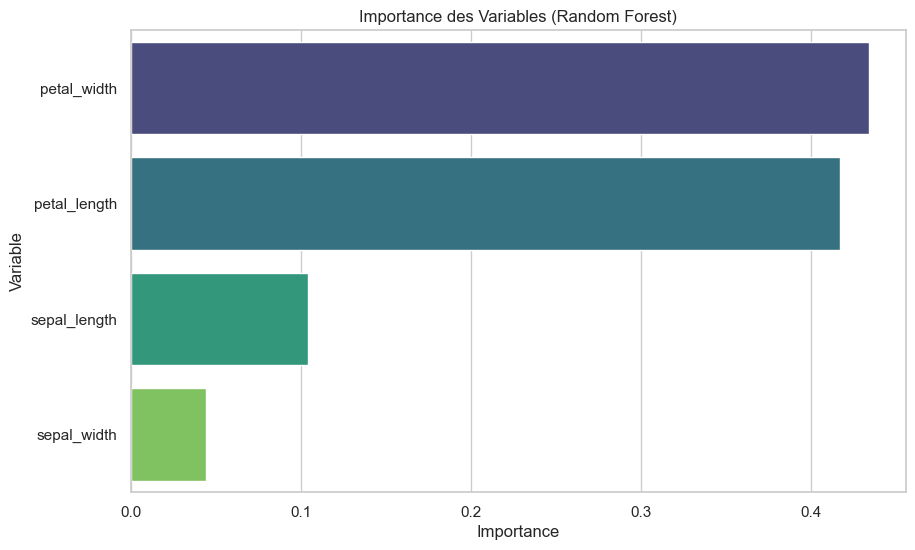

In [11]:
# Récupération des importances
importances = model.feature_importances_
features = X.columns

# Création d'un DataFrame pour l'affichage
df_imp = pd.DataFrame({'Feature': features, 'Importance': importances})
df_imp = df_imp.sort_values(by='Importance', ascending=False)

print("Importance des variables :")
print(df_imp)

# Visualisation
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_imp, palette='viridis')
plt.title("Importance des Variables (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.show()

## 🏁 Fin du TP
Vous avez exploré des données complexes, visualisé des réseaux et des séries temporelles, et entraîné un modèle de Machine Learning en comprenant ses décisions.

### Résumé des compétences acquises :
- ✅ Visualisation multidimensionnelle (Pair Plots, Parallel Coordinates)
- ✅ Graphiques interactifs avec Plotly
- ✅ Analyse de séries temporelles avec décomposition saisonnière
- ✅ Visualisation de réseaux avec NetworkX
- ✅ Machine Learning : Random Forest, Scaling, Feature Importance